# Masking in Opencv

A mask is a digital stencil.
* **Black pixels (0)**  They block out and protect the background.
* **White pixels (255)**  They let the original image shine through.


**How It Works (The Bitwise Connection)**

To apply a mask, we use  `cv.bitwise_and`.

The rule of `AND`: it only stays ON if both pixels are ON. When you `AND` a colorful image with a black-and-white mask, the math looks like this for every single pixel:

$$\text{Original Pixel Value} \times \text{Mask Pixel Value} = \text{Result}$$

* $\text{Color} \times \text{Black (0)} = \mathbf{0}\text{ (Pure Black)}$
* $\text{Color} \times \text{White (255)} = \mathbf{\text{Original Color}}$

The computer instantly ignores the black areas and extracts only the white areas.


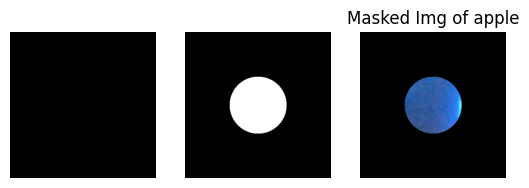

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img=cv.imread("../image/apple.jpg")
blank=np.zeros(img.shape[:2],dtype="uint8")

plt.subplot (1,3,1)
plt.imshow(blank,cmap="gray")
plt.axis("off")

mask=cv.circle(blank,(img.shape[1]//2,img.shape[0]//2),100,255,-1)
plt.subplot (1,3,2)
plt.imshow(mask,cmap="gray")
plt.axis("off")


masked_img=cv.bitwise_and(img,img,mask=mask)

plt.subplot (1,3,3)
plt.title("Masked Img of apple")
plt.imshow(masked_img,cmap="gray")
plt.axis("off")
plt.show()




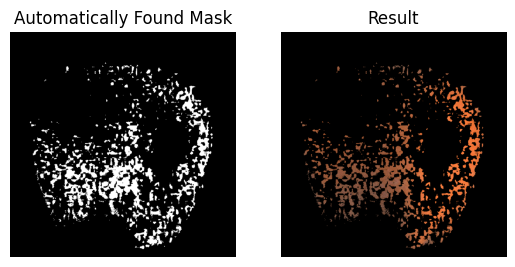

In [20]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the image
img = cv.imread("../image/apple.jpg")

# 2. Convert to HSV color space
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# 3. Define the range for the color RED
# (Red is unique because it wraps around 0 and 180, here is a typical lower range)
lower_red = np.array([0, 100, 100])
upper_red = np.array([10, 255, 255])

# 4. AUTOMATIC MASKING! 
# cv.inRange creates a mask where any pixel in the red range becomes WHITE (255)
# and everything else becomes BLACK (0). No coordinates needed!
mask = cv.inRange(hsv, lower_red, upper_red)

# 5. Cut out the apple
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
masked_apple = cv.bitwise_and(img_rgb, img_rgb, mask=mask)

# Plot the automatic result
plt.subplot(1, 2, 1)
plt.title("Automatically Found Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Result")
plt.imshow(masked_apple)
plt.axis("off")
plt.show()

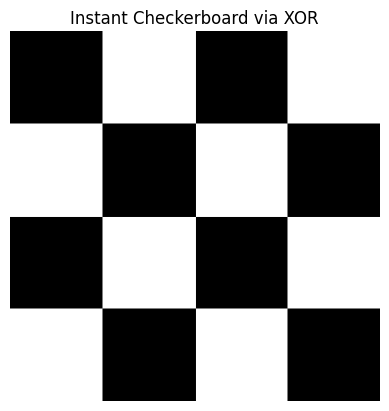

In [21]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Start with two blank black canvases
vertical_stripes = np.zeros((400, 400), dtype="uint8")
horizontal_stripes = np.zeros((400, 400), dtype="uint8")

# 2. Draw 2 vertical white bars (Columns 1 and 3)
cv.rectangle(vertical_stripes, (100, 0), (200, 400), 255, -1)
cv.rectangle(vertical_stripes, (300, 0), (400, 400), 255, -1)

# 3. Draw 2 horizontal white bars (Rows 1 and 3)
cv.rectangle(horizontal_stripes, (0, 100), (400, 200), 255, -1)
cv.rectangle(horizontal_stripes, (0, 300), (400, 400), 255, -1)

# 4. The Magic Trick: XOR them together!
checkerboard = cv.bitwise_xor(vertical_stripes, horizontal_stripes)

# 5. Display the result
plt.imshow(checkerboard, cmap="gray")
plt.axis("off")
plt.title("Instant Checkerboard via XOR")
plt.show()